In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

reading csv

In [3]:
df = pd.read_csv(
    "shopsphere_customer_rfm.csv",
    header=None,
    names=[
        "customer_id",
        "customer_name",
        "recency_days",
        "frequency",
        "monetary"
    ]
)

Inspecting data

In [4]:
df.head()

,customer_id,customer_name,recency_days,frequency,monetary
0,1,Priya Verma,53,5,54618.90
1,2,Rahul Sharma,54,2,4289.99
2,3,Vikram Iyer,509,3,38974.58
3,4,Vikram Patel,175,7,67919.21
4,5,Nikhil Joshi,129,6,55643.79


In [6]:
df.shape

(989, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    989 non-null    int64  
 1   customer_name  989 non-null    str    
 2   recency_days   989 non-null    int64  
 3   frequency      989 non-null    int64  
 4   monetary       989 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 38.8 KB


Check missing values

In [8]:
df.isnull().sum()

customer_id      0
customer_name    0
recency_days     0
frequency        0
monetary         0
dtype: int64

Check duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

Basic statistics

In [10]:
df[["recency_days", "frequency", "monetary"]].describe()

,recency_days,frequency,monetary
count,989.00000,989.000000,989.000000
mean,155.91001,4.380182,39416.932710
std,146.35664,2.037366,23978.184408
min,1.00000,1.000000,426.920000
25%,46.00000,3.000000,21094.730000
50%,113.00000,4.000000,35371.130000
75%,227.00000,6.000000,53626.920000
max,729.00000,12.000000,131082.860000


In [11]:
features = ["recency_days", "frequency", "monetary"]

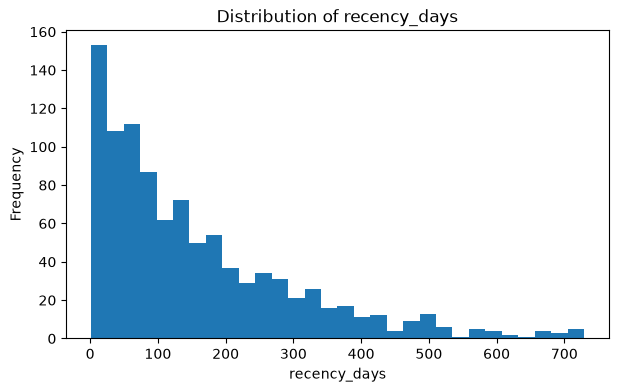

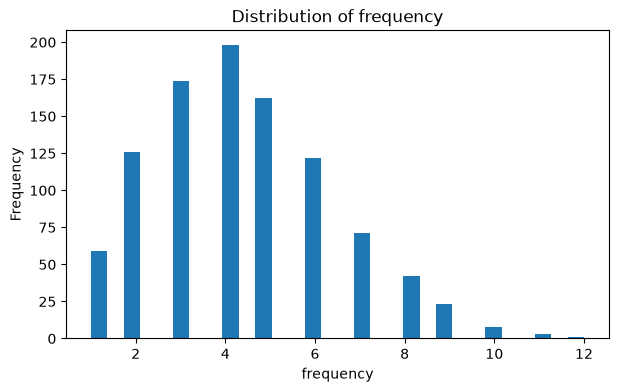

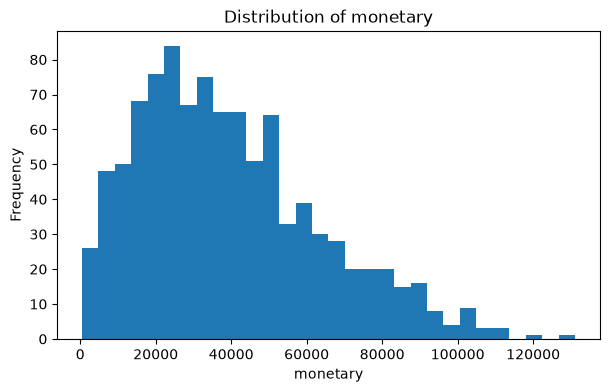

In [16]:
for col in features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

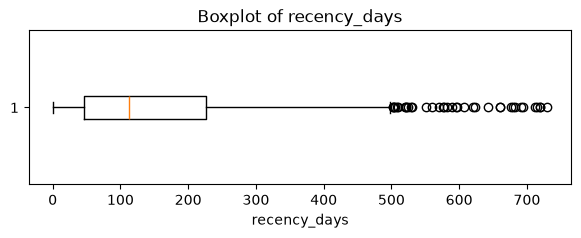

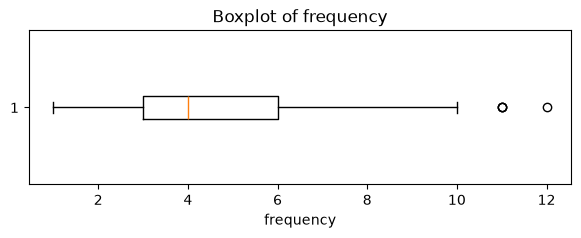

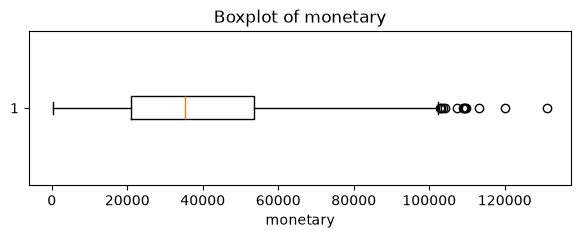

In [17]:
for col in features:
    plt.figure(figsize=(7, 2))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [18]:
rfm=df[["recency_days", "frequency", "monetary"]].copy()

In [20]:
rfm_log = np.log1p(rfm)

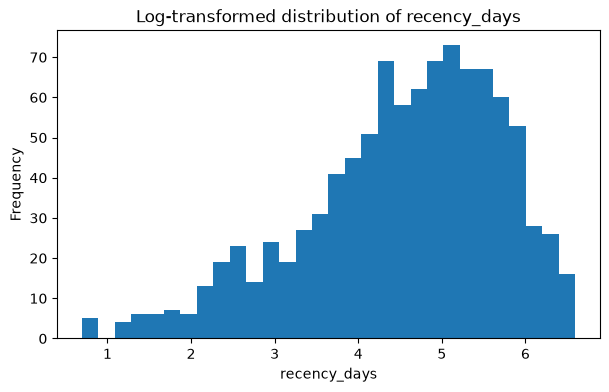

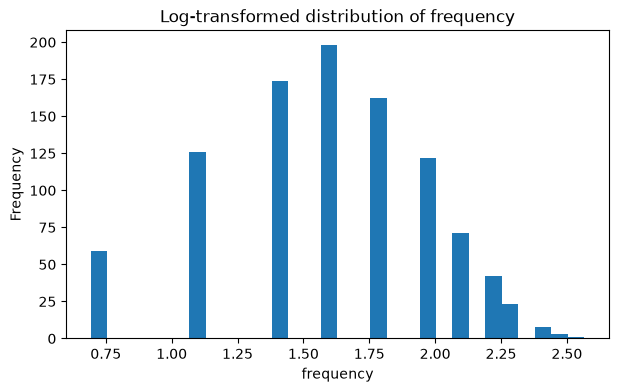

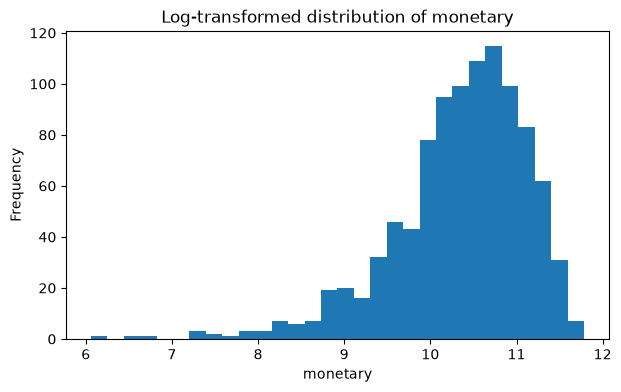

In [21]:
for col in rfm_log.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(rfm_log[col], bins=30)
    plt.title(f"Log-transformed distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [22]:
scaler= StandardScaler()

In [23]:
rfm_scaled = scaler.fit_transform(rfm_log)

In [24]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["recency_days", "frequency", "monetary"]
)

rfm_scaled.head()

,recency_days,frequency,monetary
0,-0.455296,0.460705,0.720069
1,-0.439764,-1.264230,-2.540521
2,1.445410,-0.548317,0.287530
3,0.544818,1.176618,0.999405
4,0.288378,0.844318,0.743897


In [25]:
rfm_scaled.describe().round(2)

,recency_days,frequency,monetary
count,989.00,989.00,989.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-3.25,-2.27,-5.50
25%,-0.57,-0.55,-0.50
50%,0.18,0.01,0.16
75%,0.76,0.84,0.70
max,1.75,2.38,1.84


In [26]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

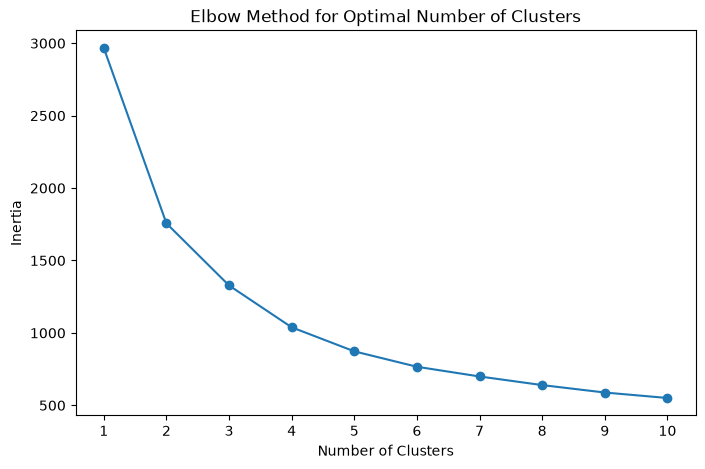

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))

plt.show()

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3669
K = 3, Silhouette Score = 0.3183
K = 4, Silhouette Score = 0.3078
K = 5, Silhouette Score = 0.3089
K = 6, Silhouette Score = 0.2881


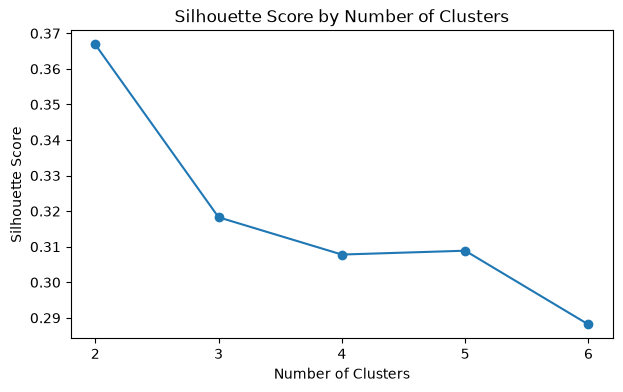

In [29]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(2, 7),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 7))

plt.show()

In [30]:
for k in [2, 3, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df[f"cluster_{k}"] = kmeans.fit_predict(rfm_scaled)

    print(f"\n--- K = {k} ---")

    print(
        df.groupby(f"cluster_{k}")[
            ["recency_days", "frequency", "monetary"]
        ]
        .mean()
        .round(2)
    )


--- K = 2 ---
           recency_days  frequency  monetary
cluster_2                                   
0                259.42       2.44  18593.54
1                100.46       5.42  50572.32

--- K = 3 ---
           recency_days  frequency  monetary
cluster_3                                   
0                 22.00       5.38  47209.41
1                160.22       5.12  48831.65
2                266.90       2.19  15909.81

--- K = 4 ---
           recency_days  frequency  monetary
cluster_4                                   
0                 17.66       4.68  38905.15
1                206.29       3.55  31061.53
2                104.33       6.49  63487.68
3                307.46       1.64  10361.84


In [31]:
df["cluster_4"].value_counts().sort_index()

cluster_4
0    176
1    373
2    301
3    139
Name: count, dtype: int64

In [32]:
df.groupby("cluster_4")[
    ["recency_days", "frequency", "monetary"]
].agg(["count", "mean"]).round(2)

recency_days         frequency       monetary          
                 count    mean     count  mean    count      mean
cluster_4                                                        
0                  176   17.66       176  4.68      176  38905.15
1                  373  206.29       373  3.55      373  31061.53
2                  301  104.33       301  6.49      301  63487.68
3                  139  307.46       139  1.64      139  10361.84

In [33]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = final_kmeans.fit_predict(rfm_scaled)

In [34]:
df.head()

,customer_id,customer_name,recency_days,frequency,monetary,cluster_2,cluster_3,cluster_4,cluster
0,1,Priya Verma,53,5,54618.90,1,1,2,2
1,2,Rahul Sharma,54,2,4289.99,0,2,3,3
2,3,Vikram Iyer,509,3,38974.58,0,1,1,1
3,4,Vikram Patel,175,7,67919.21,1,1,2,2
4,5,Nikhil Joshi,129,6,55643.79,1,1,2,2


In [35]:
segment_map = {
    0: "Recent Customers",
    1: "Cooling Customers",
    2: "High-Value Loyal Customers",
    3: "Inactive Low-Value Customers"
}

df["segment"] = df["cluster"].map(segment_map)

In [36]:
df[
    [
        "customer_id",
        "customer_name",
        "recency_days",
        "frequency",
        "monetary",
        "cluster",
        "segment"
    ]
].head(10)

,customer_id,customer_name,recency_days,frequency,monetary,cluster,segment
0,1,Priya Verma,53,5,54618.90,2,High-Value Loyal Customers
1,2,Rahul Sharma,54,2,4289.99,3,Inactive Low-Value Customers
2,3,Vikram Iyer,509,3,38974.58,1,Cooling Customers
3,4,Vikram Patel,175,7,67919.21,2,High-Value Loyal Customers
4,5,Nikhil Joshi,129,6,55643.79,2,High-Value Loyal Customers
5,7,Meera Joshi,17,4,15383.24,0,Recent Customers
6,8,Rohan Sharma,77,6,32962.25,2,High-Value Loyal Customers
7,9,Ananya Mehta,79,5,63931.95,2,High-Value Loyal Customers
8,10,Rohan Singh,208,4,44434.85,1,Cooling Customers
9,11,Vikram Shah,104,1,6396.70,3,Inactive Low-Value Customers


In [37]:
df["segment"].value_counts()

segment
Cooling Customers               373
High-Value Loyal Customers      301
Recent Customers                176
Inactive Low-Value Customers    139
Name: count, dtype: int64

In [38]:
segment_distribution = (
    df["segment"]
    .value_counts()
    .to_frame("customers")
)

segment_distribution["percentage"] = (
    segment_distribution["customers"]
    / len(df)
    * 100
).round(2)

segment_distribution

,customers,percentage
segment,,
Cooling Customers,373,37.71
High-Value Loyal Customers,301,30.43
Recent Customers,176,17.80
Inactive Low-Value Customers,139,14.05


In [39]:
segment_profile = (
    df.groupby("segment")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("recency_days", "mean"),
        Avg_Frequency=("frequency", "mean"),
        Avg_Monetary=("monetary", "mean")
    )
    .round(2)
)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
segment,,,,
Cooling Customers,373,206.29,3.55,31061.53
High-Value Loyal Customers,301,104.33,6.49,63487.68
Inactive Low-Value Customers,139,307.46,1.64,10361.84
Recent Customers,176,17.66,4.68,38905.15


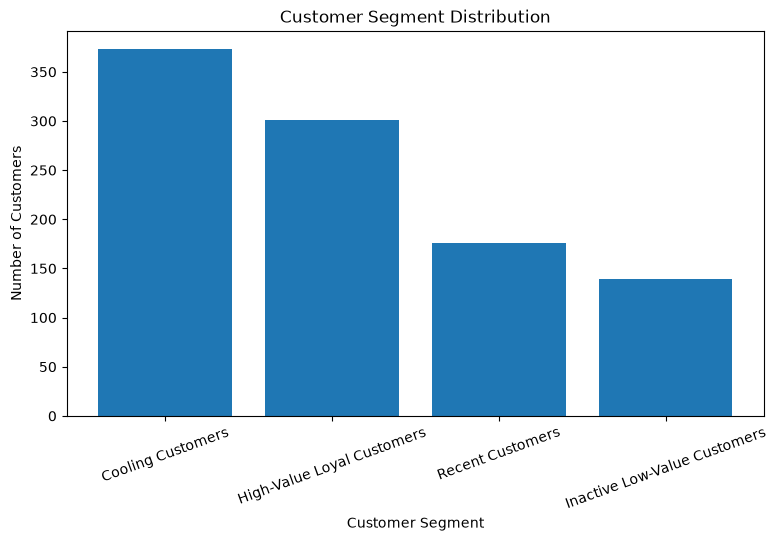

In [40]:
segment_counts = df["segment"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [41]:
profile = (
    df.groupby("segment")[
        ["recency_days", "frequency", "monetary"]
    ]
    .mean()
    .round(2)
)

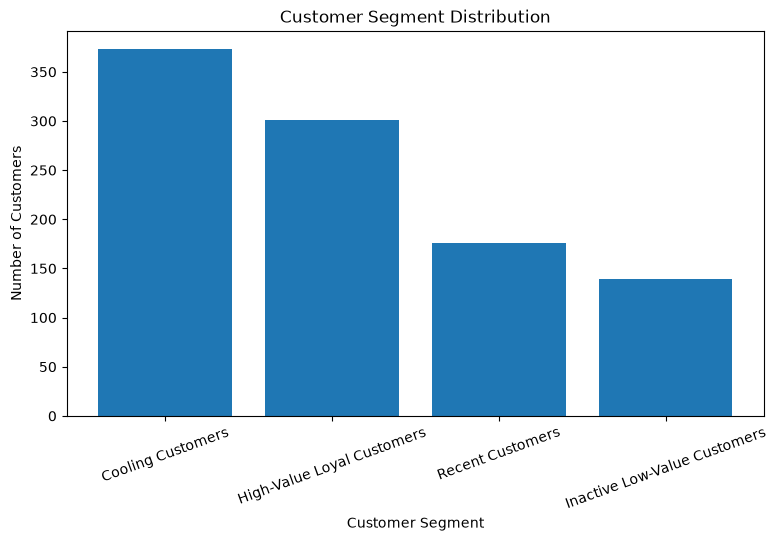

In [42]:
segment_counts = df["segment"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

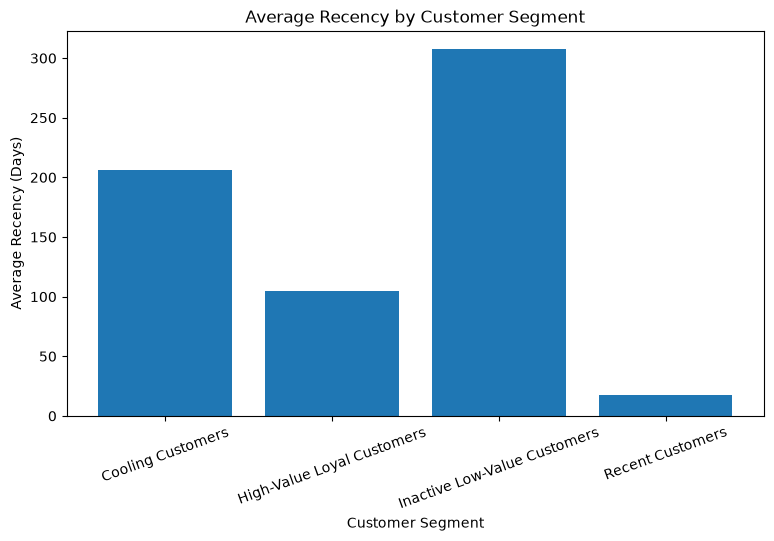

In [43]:
plt.figure(figsize=(9, 5))
plt.bar(profile.index, profile["recency_days"])

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.xticks(rotation=20)

plt.show()

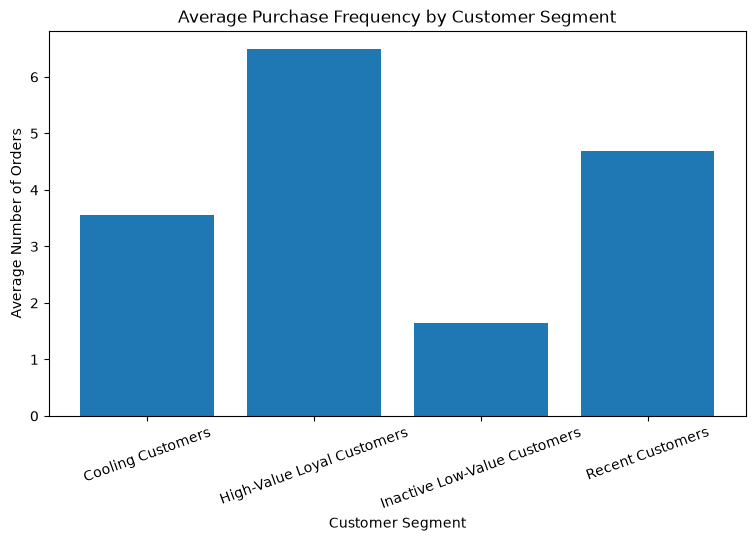

In [46]:
plt.figure(figsize=(9, 5))
plt.bar(profile.index, profile["frequency"])

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.xticks(rotation=20)

plt.show()

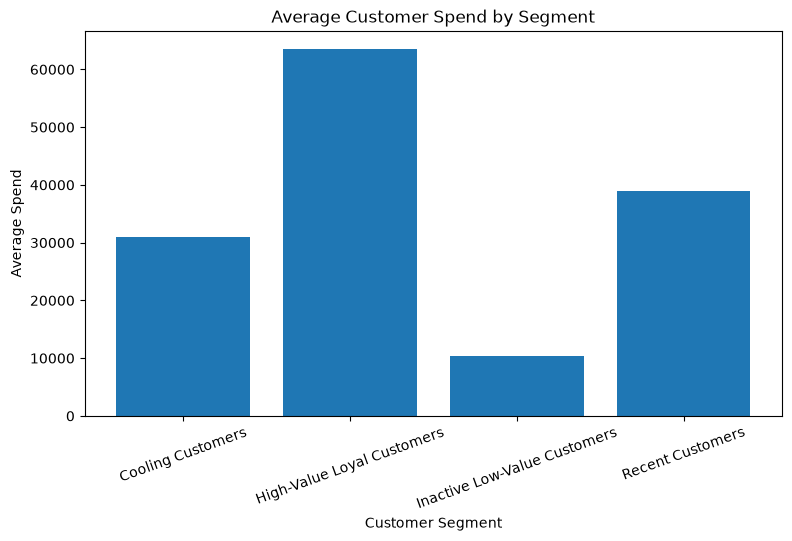

In [47]:
plt.figure(figsize=(9, 5))
plt.bar(profile.index, profile["monetary"])

plt.title("Average Customer Spend by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spend")
plt.xticks(rotation=20)

plt.show()

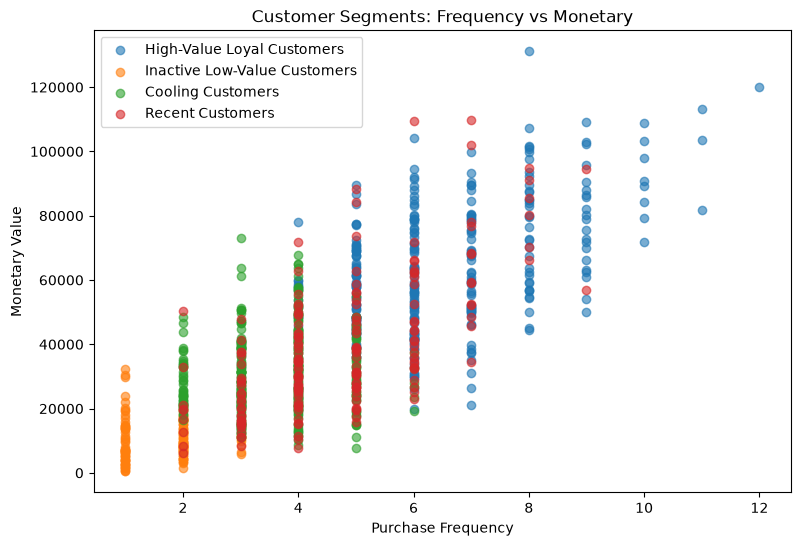

In [48]:
plt.figure(figsize=(9, 6))

for segment in df["segment"].unique():
    subset = df[df["segment"] == segment]

    plt.scatter(
        subset["frequency"],
        subset["monetary"],
        label=segment,
        alpha=0.6
    )

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend()
plt.show()

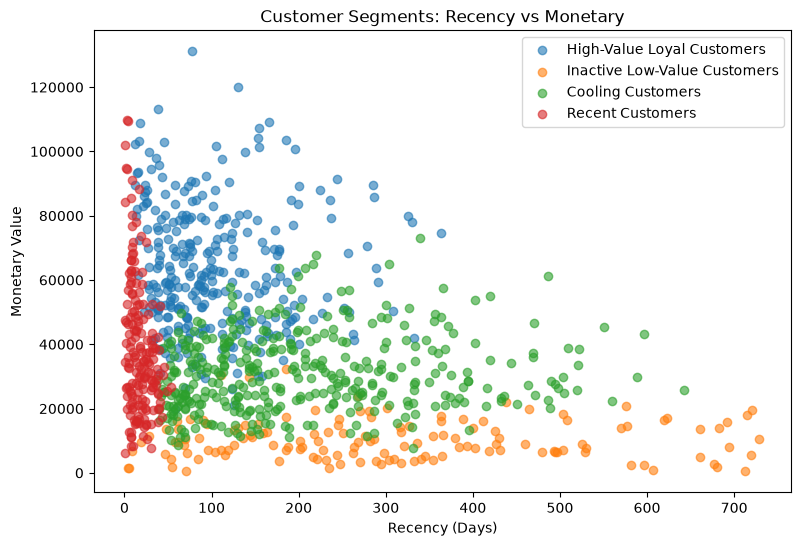

In [49]:
plt.figure(figsize=(9, 6))

for segment in df["segment"].unique():
    subset = df[df["segment"] == segment]

    plt.scatter(
        subset["recency_days"],
        subset["monetary"],
        label=segment,
        alpha=0.6
    )

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend()
plt.show()

In [50]:
final_customer_segments = df[
    [
        "customer_id",
        "customer_name",
        "recency_days",
        "frequency",
        "monetary",
        "cluster",
        "segment"
    ]
]

final_customer_segments.to_csv(
    "shopsphere_customer_segments.csv",
    index=False
)

In [51]:
final_customer_segments.head()

,customer_id,customer_name,recency_days,frequency,monetary,cluster,segment
0,1,Priya Verma,53,5,54618.90,2,High-Value Loyal Customers
1,2,Rahul Sharma,54,2,4289.99,3,Inactive Low-Value Customers
2,3,Vikram Iyer,509,3,38974.58,1,Cooling Customers
3,4,Vikram Patel,175,7,67919.21,2,High-Value Loyal Customers
4,5,Nikhil Joshi,129,6,55643.79,2,High-Value Loyal Customers
